In [16]:
!pip install statsmodels

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [2]:
titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [4]:
print(titanic.info())
print(titanic.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None
survived          int64
pclass            int64
sex              object
ag

In [5]:
titanic = titanic.drop('deck', axis=1)
titanic = titanic.drop('embarked', axis=1)
titanic['age'] = titanic['age'].fillna(titanic['age'].median())
titanic['embark_town'] = titanic['embark_town'].fillna(titanic['embark_town'].mode()[0])
titanic.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

In [6]:
titanic.dtypes

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
class          category
who              object
adult_male         bool
embark_town      object
alive            object
alone              bool
dtype: object

In [7]:
le = LabelEncoder()
titanic['sex'] = le.fit_transform(titanic['sex'])
titanic['fare'] = le.fit_transform(titanic['fare'])
titanic['class'] = le.fit_transform(titanic['class'])
titanic['who'] = le.fit_transform(titanic['who'])
titanic['embark_town'] = le.fit_transform(titanic['embark_town'])
titanic['alone'] = le.fit_transform(titanic['alone'])
titanic['alive'] = le.fit_transform(titanic['alive'])
titanic['adult_male'] = le.fit_transform(titanic['adult_male'])

In [8]:
titanic.dtypes

survived         int64
pclass           int64
sex              int64
age            float64
sibsp            int64
parch            int64
fare             int64
class            int64
who              int64
adult_male       int64
embark_town      int64
alive            int64
alone            int64
dtype: object

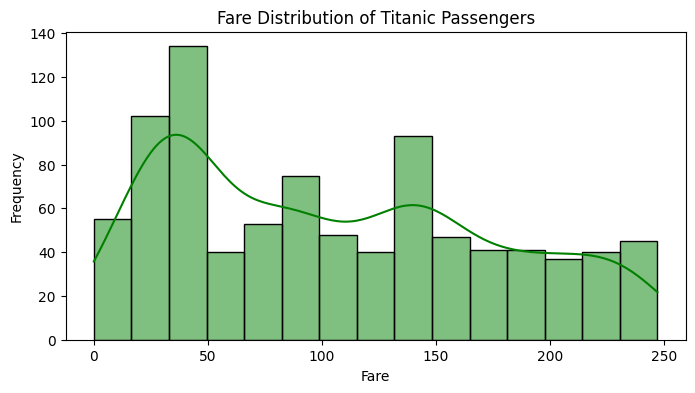

In [9]:
plt.figure(figsize=(8,4))

sns.histplot(
    data=titanic,
    x='fare',
    bins=15,
    kde=True,
    color='green',
    edgecolor='black'
)

plt.title('Fare Distribution of Titanic Passengers')

plt.xlabel('Fare')

plt.ylabel('Frequency')

plt.show()

In [10]:
# Outlier Capping using IQR Method

num_cols = [
    'age',
    'sibsp',
    'parch',
    'fare'
]

# Calculate Quartiles
Q1 = titanic[num_cols].quantile(0.25)

Q3 = titanic[num_cols].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate Bounds
LB = Q1 - (1.5 * IQR)

UB = Q3 + (1.5 * IQR)

# Detect Outliers
outliers_detected = (
    (titanic[num_cols] < LB) |
    (titanic[num_cols] > UB)
)

# Count Outliers
outlier_count = outliers_detected.sum()

# ==========================================
# OUTLIER CAPPING
# ==========================================

titanic[num_cols] = titanic[num_cols].clip(
    lower=LB,
    upper=UB,
    axis=1
)

# Summary Table
iqr_summary = pd.DataFrame({
    'Q1': Q1,
    'Q3': Q3,
    'LB': LB,
    'UB': UB,
    'Outlier Count': outlier_count
})

print(iqr_summary)

         Q1     Q3      LB      UB  Outlier Count
age    22.0   35.0    2.50   54.50             66
sibsp   0.0    1.0   -1.50    2.50             46
parch   0.0    0.0    0.00    0.00            213
fare   40.5  157.0 -134.25  331.75              0


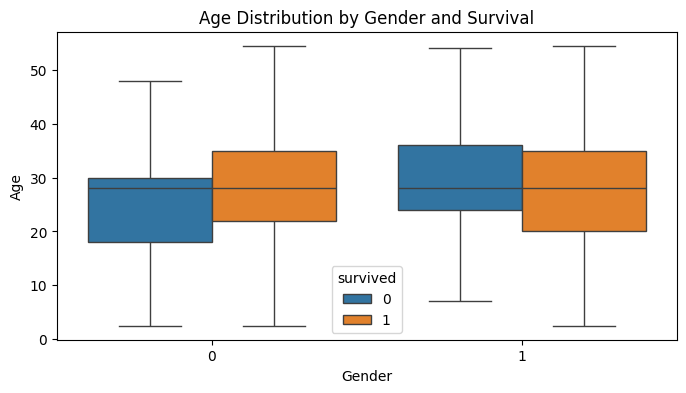

In [11]:
plt.figure(figsize=(8,4))

sns.boxplot(
    data=titanic,
    x='sex',
    y='age',
    hue='survived',
    showfliers=False
)

plt.title('Age Distribution by Gender and Survival')

plt.xlabel('Gender')

plt.ylabel('Age')

plt.show()

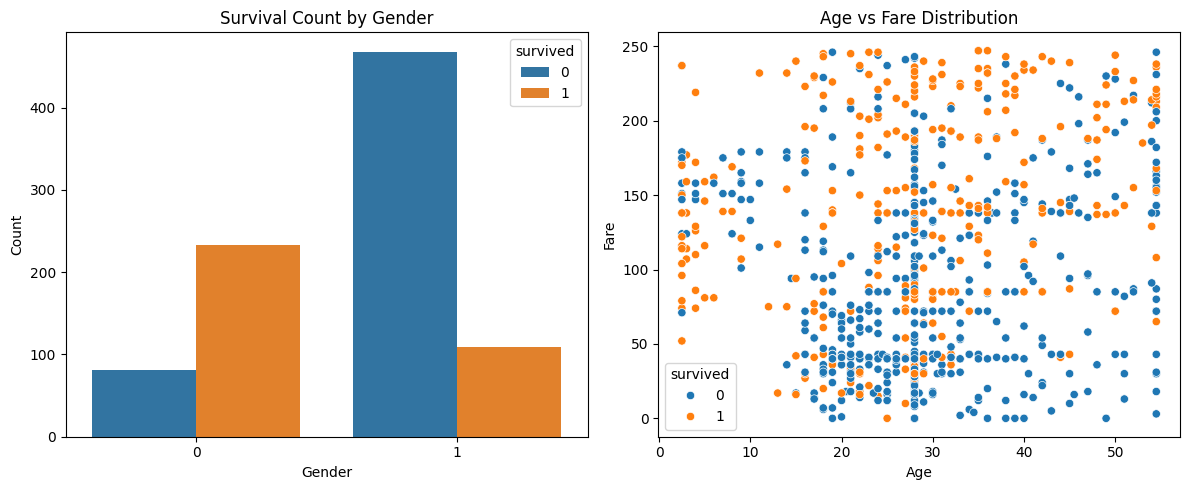

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create Figure
plt.figure(figsize=(12,5))

# ==========================================
# 1. Countplot
# ==========================================

plt.subplot(1,2,1)

sns.countplot(
    data=titanic,
    x='sex',
    hue='survived'
)

plt.title('Survival Count by Gender')

plt.xlabel('Gender')

plt.ylabel('Count')


# ==========================================
# 2. Scatterplot
# ==========================================

plt.subplot(1,2,2)

sns.scatterplot(
    data=titanic,
    x='age',
    y='fare',
    hue='survived'
)

plt.title('Age vs Fare Distribution')

plt.xlabel('Age')

plt.ylabel('Fare')


# Adjust Layout
plt.tight_layout()

# Show Graphs
plt.show()